In [1]:
import os
import warnings
import boto3
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import shap

try:
    import optuna
except ModuleNotFoundError:
    ! pip install optuna
    import optuna

try:
    import xgboost as xgb
except ModuleNotFoundError:
    ! pip install 'xgboost>=2.0,<3.0'
    import xgboost as xgb

/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


#### Functions

In [2]:
# plot optimization history
def plot_optimization_history(study, str_filename='output/optimization_history.png'):
    list_values = [trial.value for trial in study.trials if trial.value is not None]
    list_best = [max(list_values[:i+1]) for i in range(len(list_values))]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(len(list_values)), list_values, marker='o', markersize=4, alpha=0.5, color='steelblue', label='Trial AUC')
    ax.plot(range(len(list_best)), list_best, color='salmon', linewidth=2, label='Best AUC')
    ax.set_title('Optimization History', fontsize=16)
    ax.set_xlabel('Trial', fontsize=12)
    ax.set_ylabel('Validation AUC', fontsize=12)
    ax.legend()
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [3]:
# plot feature importance (gain and shap)
def plot_feature_importance(model, arr_X, list_feature_cols, str_filename='output/feature_importance.png'):
    # gain importance
    arr_gain = model.feature_importances_
    # shap importance
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(arr_X)
    arr_shap = np.abs(shap_values).mean(axis=0)
    # normalize both to 0-1 for comparison
    arr_gain_norm = arr_gain / arr_gain.max() if arr_gain.max() > 0 else arr_gain
    arr_shap_norm = arr_shap / arr_shap.max() if arr_shap.max() > 0 else arr_shap
    # build dataframe and sort by shap
    df_importance = pd.DataFrame({
        'str_feature': list_feature_cols,
        'flt_gain': arr_gain_norm,
        'flt_shap': arr_shap_norm,
    }).sort_values('flt_shap', ascending=True)
    # plot
    arr_y = np.arange(len(list_feature_cols))
    flt_bar_height = 0.35
    fig, ax = plt.subplots(figsize=(10, max(5, len(list_feature_cols) * 0.5)))
    ax.barh(arr_y + flt_bar_height / 2, df_importance['flt_gain'].values, flt_bar_height, label='Gain', color='steelblue', edgecolor='black')
    ax.barh(arr_y - flt_bar_height / 2, df_importance['flt_shap'].values, flt_bar_height, label='SHAP', color='salmon', edgecolor='black')
    ax.set_yticks(arr_y)
    ax.set_yticklabels(df_importance['str_feature'].values)
    ax.set_title('Feature Importance (Gain vs SHAP)', fontsize=16)
    ax.set_xlabel('Normalized Importance', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [4]:
# define optuna objective
def objective(trial):
    dict_params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'monotone_constraints': tpl_monotone_constraints,
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'verbosity': 0,
    }

    model = xgb.XGBClassifier(
        **dict_params,
        n_estimators=1000,
        early_stopping_rounds=50,
    )

    model.fit(
        arr_X_train, arr_y_train,
        eval_set=[(arr_X_valid, arr_y_valid)],
        verbose=False,
    )

    arr_y_pred = model.predict_proba(arr_X_valid)[:, 1]
    flt_auc = roc_auc_score(arr_y_valid, arr_y_pred)
    return flt_auc

#### Constants

In [ ]:
# bucket
str_bucket = os.getcwd().split('/')[4].replace('_', '-')
print(f'Bucket: {str_bucket}')

# step
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')

# s3 input path
str_s3_input = f's3://{str_bucket}/03_preprocessing'
print(f'S3 Input: {str_s3_input}')

# target
str_target = 'default_12m'
print(f'Target: {str_target}')

# columns to exclude from features
list_exclude_cols = [
    'loan_id',              # identifier
    'origination_date',     # used for splitting, not a feature
    'dob',                  # raw date, replaced by int_age
    'charged_off_amount',   # post-outcome leakage
    'paid_interest_amount', # post-outcome leakage
    'apr',                  # not known at time of application
    'flt_payment_to_income', # depends on apr, not known at application
    'int_age',              # excluded for fair lending compliance
    'state',                # excluded to avoid geographic discrimination concerns and sparse high-cardinality encoding
    str_target,             # target variable
]
print(f'Excluded columns: {list_exclude_cols}')

# monotone constraints (mapped to feature column order)
# -1 = higher value decreases prediction, +1 = higher value increases prediction, 0 = no constraint
dict_monotone_constraints = {
    'loan_amount': 1,              # larger loans = higher risk
    'term_months': 1,              # longer terms = higher risk
    'channel': 0,                  # categorical, no natural ordering
    'employment_length_years': -1, # longer employment = lower risk
    'stated_income': -1,           # higher income = lower risk
    'has_prior_loans_with_us': 0,  # could go either way
    'bureau_score': -1,            # higher score = lower risk
    'open_trades': 0,              # could go either way; more trades could indicate credit experience (lower risk) or over-extension (higher risk)
    'delinq_12m': 1,               # more delinquencies = higher risk
    'utilization': 1,              # higher utilization = higher risk
    'inquiries_6m': 1,             # more inquiries = higher risk
    'public_records': 1,           # more records = higher risk
}
print(f'Monotone constraints: {dict_monotone_constraints}')

# number of optuna trials
int_n_trials = 50
print(f'Optuna trials: {int_n_trials}')

# output directory
os.makedirs('output', exist_ok=True)

#### Read Data

In [6]:
# read preprocessed data
df_train = pd.read_parquet(f'{str_s3_input}/df_train_clean.parquet')
df_valid = pd.read_parquet(f'{str_s3_input}/df_valid_clean.parquet')
df_test = pd.read_parquet(f'{str_s3_input}/df_test_clean.parquet')

# print shapes
for str_name, df_split in [('Train', df_train), ('Validation', df_valid), ('Test', df_test)]:
    print(f'{str_name}: {df_split.shape}')

Train: (17715, 20)
Validation: (3796, 20)
Test: (3797, 20)


#### Data Contract Validation

In [ ]:
# data contract validation
for str_name, df_split in [('Train', df_train), ('Validation', df_valid), ('Test', df_test)]:
    assert len(df_split) > 0, f'{str_name} has no rows'
    assert str_target in df_split.columns, f'{str_name} missing target column'
    assert set(df_split[str_target].dropna().unique()).issubset({0, 1}), f'{str_name} target is not binary'

print('Data contract validation passed')

#### Define Features

Columns are excluded here rather than in preprocessing to keep the preprocessing pipeline fast and general-purpose. The following columns are excluded:
- **loan_id**: identifier with no predictive value
- **origination_date**: used for out-of-time splitting, not a model feature
- **dob**: raw date of birth, replaced by the engineered `int_age` feature
- **charged_off_amount, paid_interest_amount**: post-outcome variables that would cause data leakage
- **apr**: not known at time of application (determined during underwriting)
- **flt_payment_to_income**: derived from apr, also not known at application
- **int_age**: excluded for fair lending / ECOA compliance
- **state**: excluded from model
- **default_12m**: the target variable

Monotone constraints are applied to ensure the model's predictions move in the expected direction for each feature. This is important for credit risk models because regulators and model validators expect directional consistency (e.g., a higher bureau score should never increase predicted default probability).

In [7]:
# define feature columns
list_feature_cols = [col for col in df_train.columns if col not in list_exclude_cols]
print(f'Features ({len(list_feature_cols)}): {list_feature_cols}')

# build monotone constraints tuple in feature column order
tpl_monotone_constraints = tuple(dict_monotone_constraints.get(col, 0) for col in list_feature_cols)
print(f'Monotone constraints: {tpl_monotone_constraints}')

# separate features and target
arr_X_train = df_train[list_feature_cols].values
arr_y_train = df_train[str_target].values

arr_X_valid = df_valid[list_feature_cols].values
arr_y_valid = df_valid[str_target].values

arr_X_test = df_test[list_feature_cols].values
arr_y_test = df_test[str_target].values

Features (12): ['loan_amount', 'term_months', 'employment_length_years', 'stated_income', 'has_prior_loans_with_us', 'bureau_score', 'open_trades', 'delinq_12m', 'utilization', 'inquiries_6m', 'public_records', 'channel']
Monotone constraints: (1, 1, -1, -1, 0, -1, 0, 1, 1, 1, 1, 0)


#### Bayesian Hyperparameter Tuning

Bayesian optimization (via Optuna) is used instead of grid or random search because it models the objective function and intelligently explores the hyperparameter space, converging on good configurations faster with fewer trials.

Early stopping is used during each trial to automatically determine the optimal number of boosting rounds. This prevents overfitting and eliminates `n_estimators` as a hyperparameter to tune.

No `scale_pos_weight` or sample weights are used. The model trains on natural class distribution, which produces well-calibrated probabilities that are essential for downstream pricing and capital allocation in credit risk.

In [8]:
# run bayesian optimization
warnings.filterwarnings('ignore')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=int_n_trials, show_progress_bar=True)
warnings.filterwarnings('default')

print(f'Best trial AUC: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

[I 2026-05-01 15:42:42,378] A new study created in memory with name: no-name-325a5ee0-2fb2-4145-8172-467231c3d3b0


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-01 15:42:42,734] Trial 0 finished with value: 0.7813590296601117 and parameters: {'max_depth': 5, 'learning_rate': 0.16782616989593918, 'min_child_weight': 8, 'subsample': 0.5883317994995451, 'colsample_bytree': 0.8319693485740354, 'gamma': 1.627994058516136, 'reg_alpha': 2.2446713418735045, 'reg_lambda': 0.02414116375784027}. Best is trial 0 with value: 0.7813590296601117.
[I 2026-05-01 15:42:43,033] Trial 1 finished with value: 0.7819556670801259 and parameters: {'max_depth': 5, 'learning_rate': 0.10517316614611788, 'min_child_weight': 3, 'subsample': 0.9264144321846737, 'colsample_bytree': 0.8213034348360435, 'gamma': 4.550148241718911, 'reg_alpha': 1.0655236027923327e-07, 'reg_lambda': 1.6774133639434616}. Best is trial 1 with value: 0.7819556670801259.
[I 2026-05-01 15:42:43,496] Trial 2 finished with value: 0.7823493811670971 and parameters: {'max_depth': 5, 'learning_rate': 0.07244510043622567, 'min_child_weight': 8, 'subsample': 0.598260483159154, 'colsample_bytree':

#### Optimization History

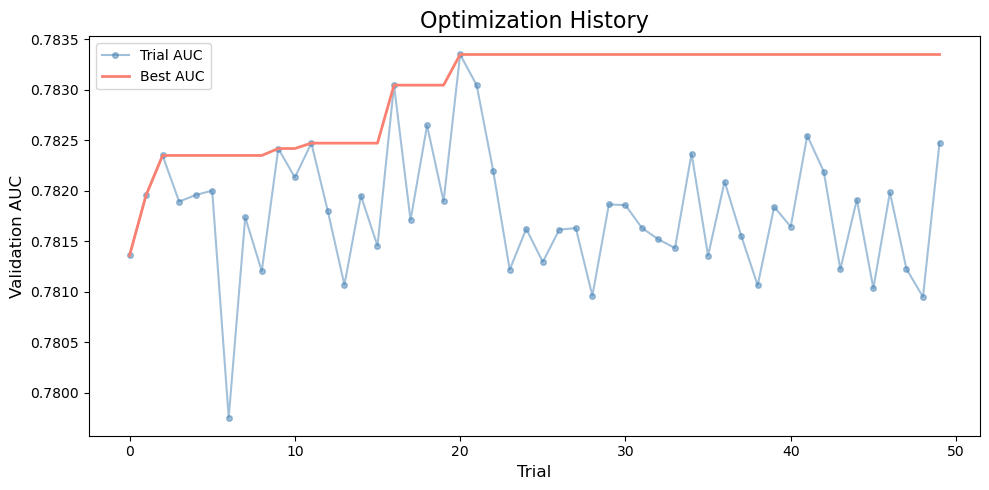

In [9]:
plot_optimization_history(study)

#### Train Final Model

The final model is trained on the combined training and validation data to maximize the amount of data available for learning. The optimal number of boosting rounds (`n_estimators`) is set to `best_iteration` from the tuning phase, which was determined via early stopping on the validation set. Since the number of rounds is now fixed, no early stopping or holdout set is needed for the final fit. The test set remains completely untouched.

In [10]:
# get best iteration from tuning phase
# reconstruct the best trial's model to extract best_iteration
dict_best_params = study.best_params.copy()
dict_best_params['objective'] = 'binary:logistic'
dict_best_params['eval_metric'] = 'auc'
dict_best_params['monotone_constraints'] = tpl_monotone_constraints
dict_best_params['verbosity'] = 0

tuning_model = xgb.XGBClassifier(
    **dict_best_params,
    n_estimators=1000,
    early_stopping_rounds=50,
)

tuning_model.fit(
    arr_X_train, arr_y_train,
    eval_set=[(arr_X_valid, arr_y_valid)],
    verbose=False,
)

int_best_iteration = tuning_model.best_iteration
print(f'Best iteration from tuning: {int_best_iteration}')

# combine train and validation data
arr_X_combined = np.vstack([arr_X_train, arr_X_valid])
arr_y_combined = np.concatenate([arr_y_train, arr_y_valid])
print(f'Combined train+valid shape: {arr_X_combined.shape}')

# train final model on combined data with fixed n_estimators
model = xgb.XGBClassifier(
    **dict_best_params,
    n_estimators=int_best_iteration,
)

model.fit(arr_X_combined, arr_y_combined, verbose=False)
print(f'Final model trained with n_estimators={int_best_iteration}')

Best iteration from tuning: 191
Combined train+valid shape: (21511, 12)
Final model trained with n_estimators=191


#### Feature Importance

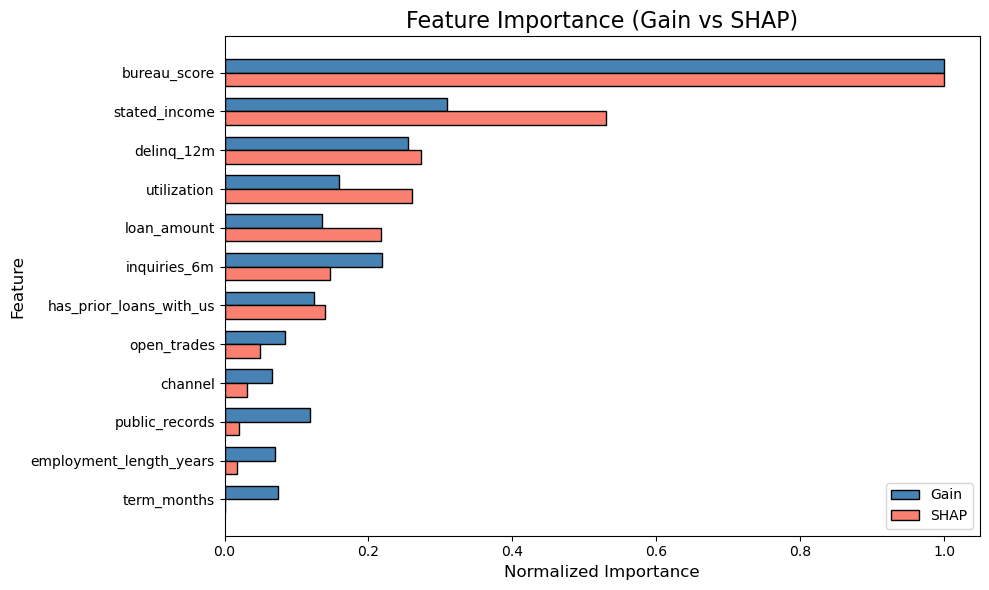

In [11]:
plot_feature_importance(model, arr_X_combined, list_feature_cols)

#### Save

In [12]:
# save model
joblib.dump(model, 'output/xgboost_model.joblib')
print('Model saved to output/xgboost_model.joblib')

# save best hyperparameters
df_params = pd.DataFrame([study.best_params])
df_params.to_csv('output/best_params.csv', index=False)
print('Best params saved to output/best_params.csv')

# save feature columns for reference
joblib.dump(list_feature_cols, 'output/feature_cols.joblib')
print('Feature columns saved to output/feature_cols.joblib')

Model saved to output/xgboost_model.joblib
Best params saved to output/best_params.csv
Feature columns saved to output/feature_cols.joblib
